# ME-XBAL (E5) — complete experiment notebook (IJIES resubmission)

This notebook reproduces **every number in the manuscript** with one *Save & Run All (Commit)* on Kaggle.

**ME-XBAL** = frozen **multilingual-E5-base** encoder + imbalance-aware hybrid head (cost-sensitive XGBoost + class-weighted Logistic Regression) + out-of-fold ensemble weighting and decision adjustment + SHAP. `ME-XBAL (XLM-R)` is the same head on XLM-RoBERTa (second instantiation, used for component attribution).

| Block | Content | Output files |
|---|---|---|
| E1/E3 | ME-XBAL, ME-XBAL (XLM-R), XLM-R/IndoBERT/E5 × LR/XGB/Hybrid, 10 seeds, SemEval + Tokopedia | `SemEval_final_raw.csv`, `Tokopedia_final_raw.csv`, `predictions/` |
| Stats | corrected resampled t-test, 95% CI, Wilcoxon, Holm, prediction bootstrap | `tables/*.csv` |
| E2 | controlled learning curve on Tokopedia: ME-XBAL vs fine-tuned E5 (and optional fine-tuned XLM-R) | `learning_curve_*.csv`, `controlled_learning_curve.png` |
| E2b | learning curve with ME-XBAL fitted on the training subset only (equal data budget) | `learning_curve_ME_XBAL_matched_budget.csv` |
| SHAP | E5 pipeline explanations + deletion/insertion faithfulness (SemEval and Tokopedia) | `SHAP/` |

**Before running on Kaggle**
1. *Add Input*: the SemEval-2025 Task 11 dataset and the PRDECT-ID dataset (paths are detected automatically). The embedding-cache dataset is optional: if it is attached it is reused, otherwise embeddings are computed and cached in `/kaggle/working/embedding_cache`.
2. *Settings*: Accelerator **GPU (T4 or P100)**, Internet **On**.
3. *Save Version → Save & Run All (Commit)*. All results are written to `/kaggle/working/ME-XBAL_E5` and zipped at the end.

Every long block writes its CSV after each step and **skips work that is already in the CSV**, so an interrupted run can be resumed by running all cells again in the same session.

In [1]:
# ============================================================
# 0. INSTALL & IMPORTS
# ============================================================
!pip -q install iterative-stratification shap

import os, sys, re, time, json, glob, random, warnings, gc, platform, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from scipy import stats
import joblib

import sklearn
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
import xgboost as xgb
import transformers
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit, MultilabelStratifiedKFold

warnings.filterwarnings("ignore")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Python", platform.python_version(), "| torch", torch.__version__, "| transformers", transformers.__version__,
      "| sklearn", sklearn.__version__, "| xgboost", xgb.__version__)
print("Device:", DEVICE, torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")

Python 3.12.13 | torch 2.10.0+cu128 | transformers 5.0.0 | sklearn 1.6.1 | xgboost 3.2.0
Device: cuda Tesla T4


## 1. Configuration

In [2]:
# ============================================================
# 1. CONFIG
# ============================================================
SMOKE_TEST = bool(int(os.environ.get("MEXBAL_SMOKE", "0")))   # keep 0 on Kaggle (full run)

SEEDS     = [42, 7, 13, 77, 101, 202, 303, 404, 505, 606]
LC_SEEDS  = [42, 7, 13, 77, 101]
SEED_PRIMARY = 42
LC_SIZES  = [100, 250, 500, 750, 1000, 1500, 2000, 2500, 3000, 3510]
MATCHED_SIZES = LC_SIZES                 # E2b sizes (equal data budget)

VAL_FRAC, TEST_FRAC = 0.15, 0.20
N_OOF_FOLDS = 5
BOOTSTRAP_REPS = 3000

# ---- switches ------------------------------------------------
RUN_MAIN          = True    # E1/E3 (+ ME-XBAL and ME-XBAL (XLM-R))
RUN_LEARNING_CURVE= True    # E2 ME-XBAL curve + E2b
RUN_FT_E5         = True    # E2 fine-tuned multilingual-E5 (encoder-matched comparator)
RUN_FT_XLMR       = False   # E2 fine-tuned XLM-R (optional, ~3 h extra GPU time)
RUN_SHAP          = True

# ---- encoders ----------------------------------------------------
ENCODERS = {
    "e5":       dict(name="intfloat/multilingual-e5-base", prefix="query: "),
    "xlmr":     dict(name="xlm-roberta-base",              prefix=None),
    "indobert": dict(name="indobenchmark/indobert-base-p1", prefix=None),
}
MAIN_ENCODER = "e5"            # encoder of ME-XBAL
MAX_LEN, EMBED_BATCH = 128, 16

# ---- fine-tuning (E2) ---------------------------------------
FT_BATCH_SIZE, FT_LR, FT_WEIGHT_DECAY = 16, 2e-5, 0.01
LC_FT_MAX_EPOCHS, LC_FT_PATIENCE = 5, 2

# ---- selection grids (identical for all models) ----------------
WEIGHT_GRID    = np.arange(0.0, 1.0001, 0.05)
THRESHOLD_GRID = np.arange(0.15, 0.8501, 0.01)
MIN_PRECISION, MAX_PPR_RATIO, TIE_TOL = 0.20, 3.0, 0.005
ALPHA_GRID, ALPHA_PASSES = np.arange(0.50, 3.0001, 0.05), 3

XGB_COMMON = dict(max_depth=3, min_child_weight=5, learning_rate=0.05, n_estimators=200,
                  subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.5,
                  verbosity=0, n_jobs=-1)
XGB_PARAMS_BINARY = dict(objective="binary:logistic", eval_metric="logloss", **XGB_COMMON)
XGB_PARAMS_MULTI  = dict(objective="multi:softprob", eval_metric="mlogloss", **XGB_COMMON)

# ---- SHAP ----------------------------------------------------
SHAP_MAX_EVALS, SHAP_BATCH_SIZE = 300, 8
SHAP_TOK_N, SHAP_SEM_PER_LANG = 30, 10
SHAP_FRACTIONS, SHAP_RANDOM_REPS = [0.10, 0.25, 0.50], 5

if SMOKE_TEST:   # tiny configuration used only to check that every cell runs
    SEEDS, LC_SEEDS = [42, 7, 13], [42, 7]
    LC_SIZES = MATCHED_SIZES = [100, 500]
    LC_FT_MAX_EPOCHS, BOOTSTRAP_REPS = 1, 200
    SHAP_TOK_N, SHAP_SEM_PER_LANG, SHAP_MAX_EVALS = 10, 2, 60

# ---- paths ------------------------------------------------------
def _find(pattern, roots=("/kaggle/input", os.environ.get("MEXBAL_DATA", "/nonexistent"))):
    for r in roots:
        hits = sorted(glob.glob(os.path.join(r, "**", pattern), recursive=True))
        if hits: return hits[0]
    return None

def _semeval_root():
    # the SemEval release contains several folders; use the one whose dev files carry gold labels
    roots = ("/kaggle/input", os.environ.get("MEXBAL_DATA", "/nonexistent"))
    hits = [h for r in roots for h in sorted(glob.glob(os.path.join(r, "**", "track_a/train/sun.csv"), recursive=True))]
    hits.sort(key=lambda h: "public_data_test" not in h)          # the folder used in the paper first
    for h in hits:
        root = Path(h).parents[2]
        need = [root / "track_a/dev/sun.csv", root / "track_c/dev/jav.csv", root / "track_c/dev/ind.csv"]
        if all(f.exists() for f in need) and all({"anger", "joy"} <= set(pd.read_csv(f, nrows=1).columns) for f in need):
            return str(root)
    return None

SEMEVAL_ROOT = _semeval_root()
assert SEMEVAL_ROOT, "SemEval-2025 Task 11 data (with labelled dev files) not found: add the dataset as Kaggle input."
TOKOPEDIA_CSV = _find("PRDECT-ID Dataset.csv") or _find("*PRDECT*.csv") or _find("Tokopedia Review.csv")
assert TOKOPEDIA_CSV, "PRDECT-ID (Tokopedia) CSV not found: add the dataset as Kaggle input."

WORK = "/kaggle/working" if os.path.isdir("/kaggle/working") else os.environ.get("MEXBAL_WORK", "./work")
OUT_ROOT  = os.path.join(WORK, "ME-XBAL_E5")
CACHE_OUT = os.path.join(WORK, "embedding_cache")
_cache_hit = _find("tokopedia_e5.npz")
CACHE_IN  = str(Path(_cache_hit).parent) if _cache_hit else None
for d in [OUT_ROOT, CACHE_OUT, f"{OUT_ROOT}/tables", f"{OUT_ROOT}/predictions", f"{OUT_ROOT}/SHAP"]:
    Path(d).mkdir(parents=True, exist_ok=True)
print("SemEval root :", SEMEVAL_ROOT)
print("Tokopedia csv:", TOKOPEDIA_CSV)
print("Cache input  :", CACHE_IN)
print("Output       :", OUT_ROOT, "| SMOKE_TEST =", SMOKE_TEST)

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

def append_csv(path, rows):
    # Append rows (list of dicts) to a CSV and return the full DataFrame
    new = pd.DataFrame(rows)
    old = pd.read_csv(path) if os.path.exists(path) else pd.DataFrame()
    df = pd.concat([old, new], ignore_index=True)
    df.to_csv(path, index=False); return df

def done_keys(path, cols):
    if not os.path.exists(path): return set()
    df = pd.read_csv(path)
    return set(map(tuple, df[cols].astype(str).values.tolist()))

SemEval root : /kaggle/input/datasets/aylinnaebzadeh/semeval-2025-task-11-emotion/public_data_test
Tokopedia csv: /kaggle/input/datasets/jocelyndumlao/prdect-id-indonesian-emotion-classification/Product Reviews Dataset for Emotions Classification Tasks - Indonesian (PRDECT-ID) Dataset/PRDECT-ID Dataset.csv
Cache input  : /kaggle/input/datasets/rezkanorhafizah/embedding-cache-me-xbal/embedding_cache
Output       : /kaggle/working/ME-XBAL_E5 | SMOKE_TEST = False


## 2. Utilities and statistics

In [3]:
# ============================================================
# 2. UTILITIES
# ============================================================
def masked_mean_pool(h, mask):
    m = mask.unsqueeze(-1).float()
    return (h * m).sum(1) / m.sum(1).clamp(min=1e-9)

def fit_preprocessor(X, seed=42):
    sc = StandardScaler().fit(X)
    pc = PCA(n_components=0.95, random_state=seed).fit(sc.transform(X))
    return (lambda A: pc.transform(sc.transform(A))), sc, pc

def corrected_ttest(d, ratio):
    # Nadeau-Bengio corrected resampled t-test on per-seed differences d
    d = np.asarray(d, float); J = len(d); m = d.mean()
    se = np.sqrt((1.0 / J + ratio) * d.var(ddof=1))
    if se == 0: return m, m, m, 1.0
    t = m / se; p = 2 * stats.t.sf(abs(t), J - 1); h = stats.t.ppf(0.975, J - 1) * se
    return m, m - h, m + h, p

def wilcoxon_p(a, b):
    d = np.asarray(a) - np.asarray(b)
    return float(stats.wilcoxon(a, b).pvalue) if np.any(d != 0) else 1.0

def holm(pvals):
    p = np.asarray(pvals, float); o = np.argsort(p); adj = np.empty_like(p); run = 0
    for r, i in enumerate(o):
        run = max(run, (len(p) - r) * p[i]); adj[i] = min(1.0, run)
    return adj

def bootstrap_mean_ci(v, reps=None, seed=42):
    reps = reps or BOOTSTRAP_REPS
    v = np.asarray(v, float); rng = np.random.default_rng(seed)
    means = v[rng.integers(0, len(v), size=(reps, len(v)))].mean(1)
    return float(v.mean()), *map(float, np.quantile(means, [0.025, 0.975]))

def paired_prediction_bootstrap(y, pa, pb, reps=None, seed=42):
    reps = reps or BOOTSTRAP_REPS
    y, pa, pb = map(np.asarray, (y, pa, pb)); rng = np.random.default_rng(seed); n = len(y)
    f = lambda yt, yp: f1_score(yt, yp, average="macro", zero_division=0)
    d = np.array([f(y[i], pa[i]) - f(y[i], pb[i]) for i in (rng.integers(0, n, n) for _ in range(reps))])
    return dict(difference=f(y, pa) - f(y, pb), ci95_low=float(np.quantile(d, .025)), ci95_high=float(np.quantile(d, .975)))

## 3. Data and fixed splits

In [4]:
# ============================================================
# 3. DATA
# ============================================================
SEMEVAL_LABELS = ["anger", "disgust", "fear", "joy", "sadness", "surprise"]

def load_semeval():
    sun = pd.concat([pd.read_csv(f"{SEMEVAL_ROOT}/track_a/train/sun.csv"),
                     pd.read_csv(f"{SEMEVAL_ROOT}/track_a/dev/sun.csv")], ignore_index=True)
    jav = pd.read_csv(f"{SEMEVAL_ROOT}/track_c/dev/jav.csv")
    ind = pd.read_csv(f"{SEMEVAL_ROOT}/track_c/dev/ind.csv")
    data = {"sun": sun.reset_index(drop=True), "jav": jav.reset_index(drop=True), "ind": ind.reset_index(drop=True)}
    for lang, df in data.items():
        assert "text" in df.columns and all(c in df.columns for c in SEMEVAL_LABELS), lang
        df["uid"] = [f"{lang}_{i:05d}" for i in range(len(df))]
    return data

def load_tokopedia():
    df = pd.read_csv(TOKOPEDIA_CSV)[["Customer Review", "Emotion"]].dropna().reset_index(drop=True)
    le = LabelEncoder(); df["label"] = le.fit_transform(df["Emotion"])
    df["uid"] = [f"tok_{i:05d}" for i in range(len(df))]
    return df, list(le.classes_)

SEMEVAL_DATA = load_semeval()
TOKO_DF, TOKO_CLASSES = load_tokopedia()

def _two_stage(splitter, y, seed):
    hold = VAL_FRAC + TEST_FRAC
    tr, h = next(splitter(n_splits=1, test_size=hold, random_state=seed).split(np.zeros(len(y)), y))
    va, te = next(splitter(n_splits=1, test_size=TEST_FRAC / hold, random_state=seed).split(np.zeros(len(h)), y[h]))
    return np.sort(tr), np.sort(h[va]), np.sort(h[te])

ALL_SEEDS = sorted(set(SEEDS) | set(LC_SEEDS) | {SEED_PRIMARY}, key=lambda s: ([42,7,13,77,101,202,303,404,505,606]+[s]).index(s))
SEMEVAL_SPLITS = {(l, s): _two_stage(MultilabelStratifiedShuffleSplit, SEMEVAL_DATA[l][SEMEVAL_LABELS].values.astype(int), s)
                  for l in SEMEVAL_DATA for s in ALL_SEEDS}
TOKO_SPLITS = {s: _two_stage(StratifiedShuffleSplit, TOKO_DF["label"].values, s) for s in ALL_SEEDS}

for (l, s), (tr, va, te) in SEMEVAL_SPLITS.items():
    assert not (set(tr) & set(va) or set(tr) & set(te) or set(va) & set(te))
for s, (tr, va, te) in TOKO_SPLITS.items():
    assert not (set(tr) & set(va) or set(tr) & set(te) or set(va) & set(te))

manifest = []
for (l, s), parts in SEMEVAL_SPLITS.items():
    for sp, idx in zip(["train", "val", "test"], parts):
        manifest += [{"dataset": "SemEval", "lang": l, "seed": s, "split": sp, "uid": SEMEVAL_DATA[l]["uid"].values[i]} for i in idx]
for s, parts in TOKO_SPLITS.items():
    for sp, idx in zip(["train", "val", "test"], parts):
        manifest += [{"dataset": "Tokopedia", "lang": "ind", "seed": s, "split": sp, "uid": TOKO_DF["uid"].values[i]} for i in idx]
pd.DataFrame(manifest).to_csv(f"{OUT_ROOT}/split_manifest_all.csv", index=False)
print("SemEval:", {l: len(d) for l, d in SEMEVAL_DATA.items()}, "| Tokopedia:", len(TOKO_DF), TOKO_CLASSES)
print("Test sizes seed 42:", {l: len(SEMEVAL_SPLITS[(l, 42)][2]) for l in SEMEVAL_DATA}, len(TOKO_SPLITS[42][2]))

SemEval: {'sun': 1123, 'jav': 151, 'ind': 156} | Tokopedia: 5400 ['Anger', 'Fear', 'Happy', 'Love', 'Sadness']
Test sizes seed 42: {'sun': 226, 'jav': 31, 'ind': 33} 1081


## 4. Frozen-encoder embeddings (cached)

In [5]:
# ============================================================
# 4. EMBEDDINGS
# ============================================================
@torch.no_grad()
def encode(texts, model, tok, prefix=None, batch=EMBED_BATCH):
    texts = [(prefix or "") + str(x) for x in texts]
    rows = []
    for i in range(0, len(texts), batch):
        enc = tok(texts[i:i + batch], padding=True, truncation=True, max_length=MAX_LEN, return_tensors="pt").to(DEVICE)
        z = masked_mean_pool(model(**enc).last_hidden_state, enc["attention_mask"])
        rows.append(F.normalize(z, p=2, dim=1).cpu().numpy())
    return np.vstack(rows)

def cached_embeddings(cache_name, texts, enc_key):
    for root in [CACHE_IN, CACHE_OUT]:
        if root and os.path.exists(f"{root}/{cache_name}.npz"):
            emb = np.load(f"{root}/{cache_name}.npz")["embedding"]
            if emb.shape[0] == len(texts):
                print("[cache]", cache_name, emb.shape); return emb
    cfg = ENCODERS[enc_key]
    tok = AutoTokenizer.from_pretrained(cfg["name"])
    model = AutoModel.from_pretrained(cfg["name"]).to(DEVICE).eval()
    emb = encode(texts, model, tok, cfg["prefix"])
    np.savez_compressed(f"{CACHE_OUT}/{cache_name}.npz", embedding=emb)
    print("[computed]", cache_name, emb.shape)
    del model, tok; gc.collect(); torch.cuda.empty_cache() if torch.cuda.is_available() else None
    return emb

SEMEVAL_EMB = {k: {l: cached_embeddings(f"semeval_{k}_{l}", SEMEVAL_DATA[l]["text"].tolist(), k) for l in SEMEVAL_DATA}
               for k in ENCODERS}
TOKO_EMB = {k: cached_embeddings(f"tokopedia_{k}", TOKO_DF["Customer Review"].tolist(), k) for k in ENCODERS}

[cache] semeval_e5_sun (1123, 768)
[cache] semeval_e5_jav (151, 768)
[cache] semeval_e5_ind (156, 768)
[cache] semeval_xlmr_sun (1123, 768)
[cache] semeval_xlmr_jav (151, 768)
[cache] semeval_xlmr_ind (156, 768)
[cache] semeval_indobert_sun (1123, 768)
[cache] semeval_indobert_jav (151, 768)
[cache] semeval_indobert_ind (156, 768)
[cache] tokopedia_e5 (5400, 768)
[cache] tokopedia_xlmr (5400, 768)
[cache] tokopedia_indobert (5400, 768)


## 5. Classifier engines (identical out-of-fold search for every model)

In [6]:
# ============================================================
# 5. MULTI-LABEL ENGINE (SemEval)
# ============================================================
class ConstantBinary:
    def __init__(self, p): self.p = float(p)
    def predict_proba(self, X): return np.c_[np.full(len(X), 1 - self.p), np.full(len(X), self.p)]

def train_ml(X, y, cfg, seed):
    xm = {} if cfg["use_xgb"] else None; lm = {} if cfg["use_lr"] else None
    for j, e in enumerate(SEMEVAL_LABELS):
        yy = y[:, j]; pos = int(yy.sum()); neg = len(yy) - pos
        if cfg["use_xgb"]:
            if pos == 0 or neg == 0: xm[e] = ConstantBinary(yy.mean())
            else:
                ratio = neg / pos if cfg["cost_sensitive"] else 1.0
                xm[e] = xgb.XGBClassifier(scale_pos_weight=ratio, random_state=seed, **XGB_PARAMS_BINARY).fit(X, yy)
        if cfg["use_lr"]:
            if pos == 0 or neg == 0: lm[e] = ConstantBinary(yy.mean())
            else:
                lm[e] = LogisticRegression(C=cfg["lr_C"], max_iter=1000, solver="lbfgs",
                                           class_weight="balanced" if cfg["lr_balanced"] else None,
                                           random_state=seed).fit(X, yy)
    return xm, lm

def proba_ml(X, xm, lm):
    px = np.column_stack([xm[e].predict_proba(X)[:, 1] for e in SEMEVAL_LABELS]) if xm is not None else None
    pl = np.column_stack([lm[e].predict_proba(X)[:, 1] for e in SEMEVAL_LABELS]) if lm is not None else None
    return px, pl

def combine(px, pl, w):
    if px is None: return pl
    if pl is None: return px
    return w * px + (1 - w) * pl

def tune_w_ml(px, pl, y):
    best = (0.5, -np.inf)
    for w in WEIGHT_GRID:
        s = f1_score(y, (combine(px, pl, w) >= 0.5).astype(int), average="macro", zero_division=0)
        if s > best[1]: best = (float(w), s)
    return best[0]

def tune_th(p, y):
    out = []
    for j in range(p.shape[1]):
        base = float(y[:, j].mean()); cap = min(1.0, max(MAX_PPR_RATIO * base, base + 0.05)); sc = []
        for t in THRESHOLD_GRID:
            yp = (p[:, j] >= t).astype(int)
            if yp.mean() > cap: sc.append(-np.inf); continue
            prec = y[:, j][yp == 1].mean() if yp.sum() else 0
            if prec < MIN_PRECISION: sc.append(-np.inf); continue
            sc.append(f1_score(y[:, j], yp, zero_division=0))
        a = np.asarray(sc)
        if not np.isfinite(a).any():
            a = np.asarray([f1_score(y[:, j], (p[:, j] >= t).astype(int), zero_division=0) for t in THRESHOLD_GRID])
        out.append(float(THRESHOLD_GRID[np.where(a >= np.nanmax(a) - TIE_TOL)[0][-1]]))
    return np.asarray(out)

def oof_ml(X, y, cfg, seed):
    px = np.zeros(y.shape) if cfg["use_xgb"] else None; pl = np.zeros(y.shape) if cfg["use_lr"] else None
    for a, b in MultilabelStratifiedKFold(n_splits=N_OOF_FOLDS, shuffle=True, random_state=seed).split(np.zeros(len(y)), y):
        tf, _, _ = fit_preprocessor(X[a], seed); xm, lm = train_ml(tf(X[a]), y[a], cfg, seed)
        qx, ql = proba_ml(tf(X[b]), xm, lm)
        if px is not None: px[b] = qx
        if pl is not None: pl[b] = ql
    return px, pl

# ============================================================
# 6. SINGLE-LABEL ENGINE (Tokopedia)
# ============================================================
def train_sl(X, y, cfg, seed):
    K = len(TOKO_CLASSES); xm = lm = None
    if cfg["use_xgb"]:
        sw = None
        if cfg["cost_sensitive"]:
            cnt = np.bincount(y, minlength=K); wt = len(y) / (K * np.maximum(cnt, 1)); sw = wt[y]
        xm = xgb.XGBClassifier(num_class=K, random_state=seed, **XGB_PARAMS_MULTI).fit(X, y, sample_weight=sw)
    if cfg["use_lr"]:
        lm = LogisticRegression(C=cfg["lr_C"], max_iter=1000, solver="lbfgs",
                                class_weight="balanced" if cfg["lr_balanced"] else None, random_state=seed).fit(X, y)
    return xm, lm

def proba_sl(X, xm, lm):
    return (xm.predict_proba(X) if xm is not None else None), (lm.predict_proba(X) if lm is not None else None)

def oof_sl(X, y, cfg, seed):
    K = len(TOKO_CLASSES)
    px = np.zeros((len(y), K)) if cfg["use_xgb"] else None; pl = np.zeros((len(y), K)) if cfg["use_lr"] else None
    for a, b in StratifiedKFold(n_splits=N_OOF_FOLDS, shuffle=True, random_state=seed).split(np.zeros(len(y)), y):
        tf, _, _ = fit_preprocessor(X[a], seed); xm, lm = train_sl(tf(X[a]), y[a], cfg, seed)
        qx, ql = proba_sl(tf(X[b]), xm, lm)
        if px is not None: px[b] = qx
        if pl is not None: pl[b] = ql
    return px, pl

def tune_w_sl(px, pl, y):
    best = (0.5, -np.inf)
    for w in WEIGHT_GRID:
        s = f1_score(y, np.argmax(combine(px, pl, w), 1), average="macro", zero_division=0)
        if s > best[1]: best = (float(w), s)
    return best[0]

def tune_alpha(p, y):
    alpha = np.ones(len(TOKO_CLASSES))
    for _ in range(ALPHA_PASSES):
        for c in range(len(alpha)):
            sc = []
            for a in ALPHA_GRID:
                q = alpha.copy(); q[c] = a
                sc.append(f1_score(y, np.argmax(p * q, 1), average="macro", zero_division=0))
            sc = np.asarray(sc); cand = np.where(sc >= sc.max() - TIE_TOL)[0]
            alpha[c] = ALPHA_GRID[cand[np.argmin(np.abs(ALPHA_GRID[cand] - 1))]]
    return alpha

## 6. Model configurations and runners

In [7]:
# ============================================================
# 7. CONFIGURATIONS
# ============================================================
def C(name, encoder, use_xgb=True, use_lr=True, cost_sensitive=False, lr_balanced=False, lr_C=1.0):
    return dict(name=name, encoder=encoder, use_xgb=use_xgb, use_lr=use_lr,
                cost_sensitive=cost_sensitive, lr_balanced=lr_balanced, lr_C=lr_C)

IMBALANCE_AWARE = dict(cost_sensitive=True, lr_balanced=True, lr_C=0.1)
ME_XBAL      = C("ME-XBAL", MAIN_ENCODER, **IMBALANCE_AWARE)          # proposed (E5)
ME_XBAL_XLMR = C("ME-XBAL (XLM-R)", "xlmr", **IMBALANCE_AWARE)        # second instantiation
CONFIGS = [
    C("XLM-R LR", "xlmr", use_xgb=False), C("XLM-R XGB", "xlmr", use_lr=False), C("XLM-R Hybrid", "xlmr"),
    C("IndoBERT LR", "indobert", use_xgb=False), C("IndoBERT XGB", "indobert", use_lr=False), C("IndoBERT Hybrid", "indobert"),
    C("E5 LR", "e5", use_xgb=False), C("E5 XGB", "e5", use_lr=False), C("E5 Hybrid", "e5"),
    ME_XBAL_XLMR, ME_XBAL,
]
print([c["name"] for c in CONFIGS])

# ============================================================
# 8. RUNNERS (return metrics + full artefacts for reproducibility)
# ============================================================
def run_sem(cfg, seed):
    E = SEMEVAL_EMB[cfg["encoder"]]
    dev = {l: np.r_[SEMEVAL_SPLITS[(l, seed)][0], SEMEVAL_SPLITS[(l, seed)][1]] for l in SEMEVAL_DATA}
    X = np.vstack([E[l][dev[l]] for l in SEMEVAL_DATA])
    y = np.vstack([SEMEVAL_DATA[l][SEMEVAL_LABELS].values.astype(int)[dev[l]] for l in SEMEVAL_DATA])
    px, pl = oof_ml(X, y, cfg, seed)
    w = tune_w_ml(px, pl, y) if (cfg["use_xgb"] and cfg["use_lr"]) else (1.0 if cfg["use_xgb"] else 0.0)
    th = tune_th(combine(px, pl, w), y)
    tf, _, _ = fit_preprocessor(X, seed); xm, lm = train_ml(tf(X), y, cfg, seed)
    rows, art = [], {"weight_xgb": w, "thresholds": th}
    for l in SEMEVAL_DATA:
        te = SEMEVAL_SPLITS[(l, seed)][2]
        yt = SEMEVAL_DATA[l][SEMEVAL_LABELS].values.astype(int)[te]
        pt = combine(*proba_ml(tf(E[l][te]), xm, lm), w); yp = (pt >= th[None, :]).astype(int)
        rows.append({"model": cfg["name"], "seed": seed, "lang": l, "n_test": len(te), "weight_xgb": w,
                     "macro_f1": f1_score(yt, yp, average="macro", zero_division=0)})
        art[l] = {"test_idx": te, "y_true": yt, "y_pred": yp, "proba": pt}
    return rows, art

def run_tok(cfg, seed, train_idx=None, val_idx=None):
    E = TOKO_EMB[cfg["encoder"]]; tr, va, te = TOKO_SPLITS[seed]
    if train_idx is not None: tr = train_idx
    if val_idx is not None: va = val_idx
    dev = np.r_[tr, va]; X = E[dev]; y = TOKO_DF.label.values[dev]
    px, pl = oof_sl(X, y, cfg, seed)
    w = tune_w_sl(px, pl, y) if (cfg["use_xgb"] and cfg["use_lr"]) else (1.0 if cfg["use_xgb"] else 0.0)
    alpha = tune_alpha(combine(px, pl, w), y)
    tf, _, _ = fit_preprocessor(X, seed); xm, lm = train_sl(tf(X), y, cfg, seed)
    pt = combine(*proba_sl(tf(E[te]), xm, lm), w); yt = TOKO_DF.label.values[te]; yp = np.argmax(pt * alpha, 1)
    row = {"model": cfg["name"], "seed": seed, "n_test": len(te), "weight_xgb": w,
           "macro_f1": f1_score(yt, yp, average="macro", zero_division=0),
           "micro_f1": f1_score(yt, yp, average="micro", zero_division=0), "accuracy": accuracy_score(yt, yp)}
    art = {"weight_xgb": w, "alpha": alpha, "test_idx": te, "y_true": yt, "y_pred": yp, "proba": pt}
    return row, art

['XLM-R LR', 'XLM-R XGB', 'XLM-R Hybrid', 'IndoBERT LR', 'IndoBERT XGB', 'IndoBERT Hybrid', 'E5 LR', 'E5 XGB', 'E5 Hybrid', 'ME-XBAL (XLM-R)', 'ME-XBAL']


## 7. E1/E3 — main comparison over ten seeds (SemEval and Tokopedia)

In [8]:
# ============================================================
# 9. MAIN EXPERIMENT (resumable)
# ============================================================
SEM_RAW, TOK_RAW = f"{OUT_ROOT}/SemEval_final_raw.csv", f"{OUT_ROOT}/Tokopedia_final_raw.csv"
if RUN_MAIN:
    for seed in SEEDS:
        sem_done = done_keys(SEM_RAW, ["model", "seed"]); tok_done = done_keys(TOK_RAW, ["model", "seed"])
        for cfg in tqdm(CONFIGS, desc=f"seed {seed}"):
            key = (cfg["name"], str(seed)); safe = re.sub(r"[^A-Za-z0-9]+", "_", cfg["name"])
            if key not in sem_done:
                rows, art = run_sem(cfg, seed); append_csv(SEM_RAW, rows)
                joblib.dump(art, f"{OUT_ROOT}/predictions/SemEval_{safe}_seed{seed}.joblib", compress=3)
            if key not in tok_done:
                row, art = run_tok(cfg, seed); append_csv(TOK_RAW, [row])
                joblib.dump(art, f"{OUT_ROOT}/predictions/Tokopedia_{safe}_seed{seed}.joblib", compress=3)
df_sem, df_tok = pd.read_csv(SEM_RAW), pd.read_csv(TOK_RAW)
print(df_sem.groupby(["model", "lang"]).macro_f1.mean().unstack().round(4))
print(df_tok.groupby("model")[["macro_f1", "micro_f1"]].mean().round(4))

seed 42:   0%|          | 0/11 [00:00<?, ?it/s]

seed 7:   0%|          | 0/11 [00:00<?, ?it/s]

seed 13:   0%|          | 0/11 [00:00<?, ?it/s]

seed 77:   0%|          | 0/11 [00:00<?, ?it/s]

seed 101:   0%|          | 0/11 [00:00<?, ?it/s]

...

seed 303:   0%|          | 0/11 [00:00<?, ?it/s]

seed 404:   0%|          | 0/11 [00:00<?, ?it/s]

seed 505:   0%|          | 0/11 [00:00<?, ?it/s]

seed 606:   0%|          | 0/11 [00:00<?, ?it/s]

lang                ind     jav     sun
model                                  
E5 Hybrid        0.3943  0.4002  0.3950
E5 LR            0.3969  0.3868  0.3967
E5 XGB           0.4148  0.3655  0.4065
IndoBERT Hybrid  0.4046  0.3218  0.3778
IndoBERT LR      0.3956  0.3346  0.3804
IndoBERT XGB     0.3804  0.3268  0.3714
ME-XBAL          0.4242  0.4367  0.4173
ME-XBAL (XLM-R)  0.4337  0.3998  0.4001
XLM-R Hybrid     0.4237  0.3917  0.3800
XLM-R LR         0.4203  0.3903  0.3793
XLM-R XGB        0.4016  0.3487  0.3615
                 macro_f1  micro_f1
model                              
E5 Hybrid          0.6163    0.6584
E5 LR              0.6049    0.6427
E5 XGB             0.5893    0.6363
IndoBERT Hybrid    0.5805    0.6260
IndoBERT LR        0.5716    0.6126
IndoBERT XGB       0.5469    0.5985
ME-XBAL            0.6324    0.6613
ME-XBAL (XLM-R)    0.6061    0.6335
XLM-R Hybrid       0.5909    0.6339
XLM-R LR           0.5846    0.6253
XLM-R XGB          0.5453    0.5903


## 8. Statistics and manuscript tables

In [9]:
# ============================================================
# 10. STATISTICS (corrected resampled t-test, Wilcoxon, Holm)
# ============================================================
ORDER = [c["name"] for c in CONFIGS]
REF = "ME-XBAL"
RATIO_SEM = 0.20 / 0.80                         # n_test / n_dev
RATIO_TOK = len(TOKO_SPLITS[SEED_PRIMARY][2]) / (len(TOKO_SPLITS[SEED_PRIMARY][0]) + len(TOKO_SPLITS[SEED_PRIMARY][1]))
ms = lambda v: f"{np.mean(v):.4f} ± {np.std(v, ddof=1):.4f}"

def compare(piv, ref, ratio, models):
    rows = []
    for m in models:
        if m == ref: continue
        d = (piv[ref] - piv[m]).values; mm, lo, hi, p = corrected_ttest(d, ratio)
        rows.append(dict(comparison=f"{ref} vs {m}", delta=mm, ci95_low=lo, ci95_high=hi, p_corrected=p,
                         p_wilcoxon=wilcoxon_p(piv[ref], piv[m]), wins=int((d > 0).sum()), n_seeds=len(d)))
    out = pd.DataFrame(rows); out["p_holm"] = holm(out.p_corrected); return out

sem_avg = df_sem.pivot_table(index="seed", columns="model", values="macro_f1", aggfunc="mean")
tok_piv = df_tok.pivot(index="seed", columns="model", values="macro_f1")

# Table: SemEval per language (mean ± SD)
t_sem = pd.DataFrame([{"model": m, **{l: ms(df_sem[(df_sem.model == m) & (df_sem.lang == l)].macro_f1) for l in ["sun", "jav", "ind"]},
                       "average": ms(sem_avg[m])} for m in ORDER])
t_sem_cmp = compare(sem_avg, REF, RATIO_SEM, ORDER)
t_sem_lang = pd.concat([compare(df_sem[df_sem.lang == l].pivot(index="seed", columns="model", values="macro_f1"), REF, RATIO_SEM, ORDER)
                        .assign(lang=l) for l in ["sun", "jav", "ind"]])
t_tok = pd.DataFrame([{"model": m, "macro_f1": ms(tok_piv[m]), "micro_f1": df_tok[df_tok.model == m].micro_f1.mean()} for m in ORDER])
t_tok_cmp = compare(tok_piv, REF, RATIO_TOK, ORDER)

# One-factor contrasts
CONTRASTS = [("Imbalance-aware fitting, E5 (ME-XBAL − E5 Hybrid)", "ME-XBAL", "E5 Hybrid"),
             ("Imbalance-aware fitting, XLM-R (ME-XBAL (XLM-R) − XLM-R Hybrid)", "ME-XBAL (XLM-R)", "XLM-R Hybrid"),
             ("Boosting branch, E5 (E5 Hybrid − E5 LR)", "E5 Hybrid", "E5 LR"),
             ("Boosting branch, XLM-R (XLM-R Hybrid − XLM-R LR)", "XLM-R Hybrid", "XLM-R LR"),
             ("LR branch, E5 (E5 Hybrid − E5 XGB)", "E5 Hybrid", "E5 XGB"),
             ("Encoder, E5 vs. XLM-R (Hybrid)", "E5 Hybrid", "XLM-R Hybrid"),
             ("Encoder, E5 vs. XLM-R (imbalance-aware head)", "ME-XBAL", "ME-XBAL (XLM-R)"),
             ("Encoder, XLM-R vs. IndoBERT (Hybrid)", "XLM-R Hybrid", "IndoBERT Hybrid")]
rows = []
for lab, a, b in CONTRASTS:
    r = {"contrast": lab}
    for nm, piv, ratio in [("semeval", sem_avg, RATIO_SEM), ("tokopedia", tok_piv, RATIO_TOK)]:
        mm, lo, hi, p = corrected_ttest(piv[a] - piv[b], ratio)
        r.update({f"{nm}_delta": mm, f"{nm}_ci_low": lo, f"{nm}_ci_high": hi, f"{nm}_p": p,
                  f"{nm}_wins": int(((piv[a] - piv[b]) > 0).sum())})
    rows.append(r)
t_contrast = pd.DataFrame(rows)

# Selected XGBoost weights
t_weights = pd.concat([df_sem.groupby("model").weight_xgb.mean().rename("semeval"),
                       df_tok.groupby("model").weight_xgb.mean().rename("tokopedia")], axis=1)

for name, t in [("table_semeval", t_sem), ("table_semeval_comparison", t_sem_cmp), ("table_semeval_per_language", t_sem_lang),
                ("table_tokopedia", t_tok), ("table_tokopedia_comparison", t_tok_cmp), ("table_contrasts", t_contrast),
                ("table_selected_weights", t_weights.reset_index())]:
    t.to_csv(f"{OUT_ROOT}/tables/{name}.csv", index=False)
pd.set_option("display.width", 250)
print(t_sem.to_string(index=False)); print(t_sem_cmp.round(4).to_string(index=False))
print(t_tok.to_string(index=False)); print(t_tok_cmp.round(4).to_string(index=False))
print(t_contrast.round(4).to_string(index=False))

          model             sun             jav             ind         average
       XLM-R LR 0.3793 ± 0.0216 0.3903 ± 0.0399 0.4203 ± 0.0698 0.3966 ± 0.0330
      XLM-R XGB 0.3615 ± 0.0275 0.3487 ± 0.0419 0.4016 ± 0.0739 0.3706 ± 0.0278
   XLM-R Hybrid 0.3800 ± 0.0205 0.3917 ± 0.0378 0.4237 ± 0.0676 0.3984 ± 0.0312
    IndoBERT LR 0.3804 ± 0.0303 0.3346 ± 0.0657 0.3956 ± 0.0528 0.3702 ± 0.0280
   IndoBERT XGB 0.3714 ± 0.0400 0.3268 ± 0.0379 0.3804 ± 0.0506 0.3595 ± 0.0181
IndoBERT Hybrid 0.3778 ± 0.0291 0.3218 ± 0.0617 0.4046 ± 0.0404 0.3681 ± 0.0233
          E5 LR 0.3967 ± 0.0198 0.3868 ± 0.0727 0.3969 ± 0.0793 0.3935 ± 0.0323
         E5 XGB 0.4065 ± 0.0237 0.3655 ± 0.0572 0.4148 ± 0.0818 0.3956 ± 0.0325
      E5 Hybrid 0.3950 ± 0.0150 0.4002 ± 0.0712 0.3943 ± 0.0649 0.3965 ± 0.0355
ME-XBAL (XLM-R) 0.4001 ± 0.0161 0.3998 ± 0.0455 0.4337 ± 0.0561 0.4112 ± 0.0272
        ME-XBAL 0.4173 ± 0.0266 0.4367 ± 0.0684 0.4242 ± 0.0509 0.4261 ± 0.0261
                comparison  delta  ci95_

In [10]:
# ============================================================
# 11. PRIMARY-SEED PAIRED PREDICTION BOOTSTRAP
# ============================================================
def load_art(ds, name, seed):
    return joblib.load(f"{OUT_ROOT}/predictions/{ds}_{re.sub(r'[^A-Za-z0-9]+', '_', name)}_seed{seed}.joblib")

ref_tok = load_art("Tokopedia", REF, SEED_PRIMARY); ref_sem = load_art("SemEval", REF, SEED_PRIMARY)
rows = []
for m in ORDER:
    if m == REF: continue
    a = load_art("Tokopedia", m, SEED_PRIMARY)
    rows.append({"dataset": "Tokopedia", "lang": "ind", "comparison": f"{REF} - {m}",
                 **paired_prediction_bootstrap(ref_tok["y_true"], ref_tok["y_pred"], a["y_pred"])})
    a = load_art("SemEval", m, SEED_PRIMARY)
    for l in SEMEVAL_DATA:
        rows.append({"dataset": "SemEval", "lang": l, "comparison": f"{REF} - {m}",
                     **paired_prediction_bootstrap(ref_sem[l]["y_true"], ref_sem[l]["y_pred"], a[l]["y_pred"])})
t_boot = pd.DataFrame(rows); t_boot.to_csv(f"{OUT_ROOT}/tables/table_primary_seed_bootstrap.csv", index=False)
print(t_boot.round(4).to_string(index=False))

  dataset lang                comparison  difference  ci95_low  ci95_high
Tokopedia  ind        ME-XBAL - XLM-R LR      0.0439    0.0090     0.0794
  SemEval  sun        ME-XBAL - XLM-R LR      0.0716   -0.0061     0.1464
  SemEval  jav        ME-XBAL - XLM-R LR      0.0676   -0.0895     0.2031
  SemEval  ind        ME-XBAL - XLM-R LR      0.0202   -0.1491     0.1655
Tokopedia  ind       ME-XBAL - XLM-R XGB      0.0994    0.0641     0.1350
  SemEval  sun       ME-XBAL - XLM-R XGB      0.0637   -0.0077     0.1323
  SemEval  jav       ME-XBAL - XLM-R XGB      0.1171   -0.0432     0.2586
  SemEval  ind       ME-XBAL - XLM-R XGB      0.0188   -0.1504     0.1610
Tokopedia  ind    ME-XBAL - XLM-R Hybrid      0.0445    0.0108     0.0802
  SemEval  sun    ME-XBAL - XLM-R Hybrid      0.0716   -0.0061     0.1464
  SemEval  jav    ME-XBAL - XLM-R Hybrid      0.0676   -0.0895     0.2031
  SemEval  ind    ME-XBAL - XLM-R Hybrid      0.0202   -0.1491     0.1655
Tokopedia  ind     ME-XBAL - IndoBERT 

## 9. E2/E2b — controlled learning curve on Tokopedia (ME-XBAL with E5)

In [11]:
# ============================================================
# 12. LEARNING CURVE: ME-XBAL (E2) and equal-budget ME-XBAL (E2b)
# ============================================================
def stratified_subset(full_train, n, seed):
    if n >= len(full_train): return np.asarray(full_train)
    a, _ = next(StratifiedShuffleSplit(n_splits=1, train_size=n, random_state=seed)
                .split(np.zeros(len(full_train)), TOKO_DF.label.values[full_train]))
    return np.asarray(full_train)[a]

def lc_split(seed, n):
    tr, va, te = TOKO_SPLITS[seed]
    return stratified_subset(tr, n, seed + 10000 + n), va, te

LC_ME, LC_ME_B = f"{OUT_ROOT}/learning_curve_ME_XBAL.csv", f"{OUT_ROOT}/learning_curve_ME_XBAL_matched_budget.csv"
EMPTY = np.array([], dtype=int)
if RUN_LEARNING_CURVE:
    for seed in LC_SEEDS:
        for n in LC_SIZES:
            if (str(seed), str(n)) in done_keys(LC_ME, ["seed", "train_size"]): continue
            tr, va, te = lc_split(seed, n); t0 = time.perf_counter()
            r, _ = run_tok(ME_XBAL, seed, tr, va)          # subset + validation (as in the main pipeline)
            r.update(train_size=n, fit_time_s=time.perf_counter() - t0); append_csv(LC_ME, [r])
        for n in MATCHED_SIZES:
            if (str(seed), str(n)) in done_keys(LC_ME_B, ["seed", "train_size"]): continue
            tr, va, te = lc_split(seed, n); t0 = time.perf_counter()
            r, _ = run_tok(ME_XBAL, seed, tr, EMPTY)       # training subset only (equal data budget)
            r.update(train_size=n, fit_time_s=time.perf_counter() - t0, model="ME-XBAL (train subset only)")
            append_csv(LC_ME_B, [r])
        print("learning curve seed", seed, "done")

learning curve seed 42 done
learning curve seed 7 done
learning curve seed 13 done
learning curve seed 77 done
learning curve seed 101 done


In [12]:
# ============================================================
# 13. FINE-TUNED COMPARATOR(S) FOR THE LEARNING CURVE
# ============================================================
from torch.utils.data import Dataset, DataLoader

class TxtDS(Dataset):
    def __init__(self, texts, y, tok, prefix):
        self.enc = tok([(prefix or "") + str(x) for x in texts], padding="max_length", truncation=True,
                       max_length=MAX_LEN, return_tensors="pt")
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return {k: v[i] for k, v in self.enc.items()} | {"labels": self.y[i]}

@torch.no_grad()
def ft_predict(model, tok, texts, prefix):
    model.eval(); out = []
    for i in range(0, len(texts), 64):
        enc = tok([(prefix or "") + str(x) for x in texts[i:i + 64]], padding=True, truncation=True,
                  max_length=MAX_LEN, return_tensors="pt").to(DEVICE)
        out.append(torch.softmax(model(**enc).logits, -1).cpu().numpy())
    return np.vstack(out)

def run_ft(enc_key, size, seed):
    set_seed(seed)
    cfg = ENCODERS[enc_key]; tr, va, te = lc_split(seed, size); y = TOKO_DF.label.values
    texts = TOKO_DF["Customer Review"].values
    tok = AutoTokenizer.from_pretrained(cfg["name"])
    model = AutoModelForSequenceClassification.from_pretrained(cfg["name"], num_labels=len(TOKO_CLASSES)).to(DEVICE)
    dl = DataLoader(TxtDS(texts[tr], y[tr], tok, cfg["prefix"]), batch_size=FT_BATCH_SIZE, shuffle=True,
                    generator=torch.Generator().manual_seed(seed))
    opt = torch.optim.AdamW(model.parameters(), lr=FT_LR, weight_decay=FT_WEIGHT_DECAY)
    best, best_state, pat, epochs, t0 = -1.0, None, LC_FT_PATIENCE, 0, time.perf_counter()
    for ep in range(LC_FT_MAX_EPOCHS):
        model.train(); epochs += 1
        for batch in dl:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            opt.zero_grad(); model(**batch).loss.backward(); opt.step()
        f = f1_score(y[va], ft_predict(model, tok, texts[va], cfg["prefix"]).argmax(1), average="macro", zero_division=0)
        if f > best + 1e-6:
            best, pat = f, LC_FT_PATIENCE; best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            pat -= 1
            if pat <= 0: break
    model.load_state_dict(best_state); train_time = time.perf_counter() - t0
    yp = ft_predict(model, tok, texts[te], cfg["prefix"]).argmax(1)
    out = {"model": f"{'E5' if enc_key == 'e5' else 'XLM-R'} fine-tuned", "seed": seed, "train_size": size,
           "macro_f1": f1_score(y[te], yp, average="macro", zero_division=0),
           "micro_f1": f1_score(y[te], yp, average="micro", zero_division=0),
           "accuracy": accuracy_score(y[te], yp), "best_val_macro_f1": best, "epochs_run": epochs,
           "n_pred_classes": int(len(np.unique(yp))), "train_time_s": train_time}
    del model, tok, dl, opt; gc.collect(); torch.cuda.empty_cache() if torch.cuda.is_available() else None
    return out

FT_FILES = {"e5": f"{OUT_ROOT}/learning_curve_E5_finetuned.csv", "xlmr": f"{OUT_ROOT}/learning_curve_XLMR_finetuned.csv"}
for enc_key, flag in [("e5", RUN_FT_E5), ("xlmr", RUN_FT_XLMR)]:
    if not flag: continue
    for seed in LC_SEEDS:
        for n in LC_SIZES:
            if (str(seed), str(n)) in done_keys(FT_FILES[enc_key], ["seed", "train_size"]): continue
            r = run_ft(enc_key, n, seed); append_csv(FT_FILES[enc_key], [r])
            print(f"FT {enc_key} seed={seed} n={n} macroF1={r['macro_f1']:.4f} ({r['train_time_s']:.0f}s)")

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/418 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

...

XLMRobertaForSequenceClassification LOAD REPORT from: intfloat/multilingual-e5-base
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.bias          | UNEXPECTED | 
pooler.dense.weight        | UNEXPECTED | 
embeddings.position_ids    | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


FT e5 seed=101 n=3000 macroF1=0.6614 (436s)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: intfloat/multilingual-e5-base
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.bias          | UNEXPECTED | 
pooler.dense.weight        | UNEXPECTED | 
embeddings.position_ids    | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


FT e5 seed=101 n=3510 macroF1=0.6602 (505s)


   comparator                      frozen  train_size  frozen_mean  frozen_sd  ft_mean  ft_sd   delta  ci95_low  ci95_high  frozen_wins  ft_collapsed_seeds  ft_time_s  n_seeds
E5 fine-tuned                     ME-XBAL         100       0.5674     0.0092   0.3109 0.0360  0.2565    0.2293     0.2813            5                   0    44.4836        5
E5 fine-tuned                     ME-XBAL         250       0.5772     0.0154   0.4658 0.0435  0.1114    0.0895     0.1332            5                   0    64.6773        5
E5 fine-tuned                     ME-XBAL         500       0.5644     0.0119   0.5812 0.0183 -0.0167   -0.0408     0.0067            1                   0    98.6223        5
E5 fine-tuned                     ME-XBAL         750       0.5739     0.0144   0.6214 0.0124 -0.0474   -0.0532    -0.0417            0                   0   132.8544        5
E5 fine-tuned                     ME-XBAL        1000       0.5984     0.0058   0.6372 0.0204 -0.0389   -0.0554    -0.01

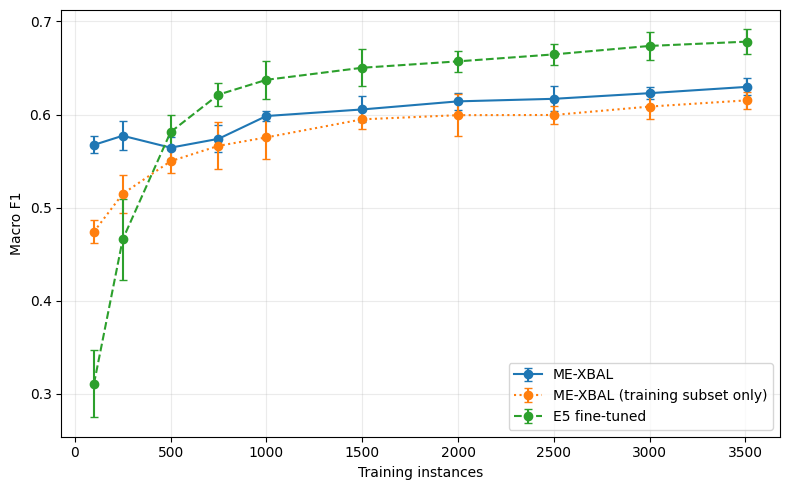

In [13]:
# ============================================================
# 14. LEARNING-CURVE ANALYSIS, TABLE AND FIGURE
# ============================================================
lc_me = pd.read_csv(LC_ME); lc_me_b = pd.read_csv(LC_ME_B) if os.path.exists(LC_ME_B) else pd.DataFrame()
ft = {k: pd.read_csv(p) for k, p in FT_FILES.items() if os.path.exists(p)}
rows = []
for k, f in ft.items():
    for label, me in [("ME-XBAL", lc_me), ("ME-XBAL (train subset only)", lc_me_b)]:
        if me.empty: continue
        m = me.merge(f, on=["seed", "train_size"], suffixes=("_me", "_ft"))
        for n, g in m.groupby("train_size"):
            d = (g.macro_f1_me - g.macro_f1_ft).values; _, lo, hi = bootstrap_mean_ci(d)
            rows.append({"comparator": f.model.iloc[0], "frozen": label, "train_size": n,
                         "frozen_mean": g.macro_f1_me.mean(), "frozen_sd": g.macro_f1_me.std(ddof=1),
                         "ft_mean": g.macro_f1_ft.mean(), "ft_sd": g.macro_f1_ft.std(ddof=1),
                         "delta": d.mean(), "ci95_low": lo, "ci95_high": hi, "frozen_wins": int((d > 0).sum()),
                         "ft_collapsed_seeds": int((g.n_pred_classes == 1).sum()) if "n_pred_classes" in g else np.nan,
                         "ft_time_s": g.train_time_s.mean(), "n_seeds": len(d)})
t_lc = pd.DataFrame(rows); t_lc.to_csv(f"{OUT_ROOT}/tables/table_learning_curve.csv", index=False)
print(t_lc.round(4).to_string(index=False))

plt.figure(figsize=(8, 5))
def _plot(df, label, style):
    g = df.groupby("train_size").macro_f1.agg(["mean", "std"]).reset_index()
    plt.errorbar(g.train_size, g["mean"], yerr=g["std"], marker="o", capsize=3, label=label, ls=style)
_plot(lc_me, "ME-XBAL", "-")
if not lc_me_b.empty: _plot(lc_me_b, "ME-XBAL (training subset only)", ":")
for k, f in ft.items(): _plot(f, f.model.iloc[0], "--")
plt.xlabel("Training instances"); plt.ylabel("Macro F1"); plt.grid(alpha=.25); plt.legend(); plt.tight_layout()
plt.savefig(f"{OUT_ROOT}/controlled_learning_curve.png", dpi=300); plt.show()

## 10. SHAP explanations and faithfulness (E5 pipeline)

In [14]:
# ============================================================
# 15. SHAP SET-UP: primary-seed ME-XBAL models and raw-text predictors
# ============================================================
import shap
print("SHAP", shap.__version__)
SHAP_ROOT = f"{OUT_ROOT}/SHAP"
ENC = ENCODERS[MAIN_ENCODER]

def fit_bundle_sem(seed=SEED_PRIMARY):
    E = SEMEVAL_EMB[MAIN_ENCODER]
    dev = {l: np.r_[SEMEVAL_SPLITS[(l, seed)][0], SEMEVAL_SPLITS[(l, seed)][1]] for l in SEMEVAL_DATA}
    X = np.vstack([E[l][dev[l]] for l in SEMEVAL_DATA])
    y = np.vstack([SEMEVAL_DATA[l][SEMEVAL_LABELS].values.astype(int)[dev[l]] for l in SEMEVAL_DATA])
    px, pl = oof_ml(X, y, ME_XBAL, seed); w = tune_w_ml(px, pl, y); th = tune_th(combine(px, pl, w), y)
    tf, sc, pc = fit_preprocessor(X, seed); xm, lm = train_ml(tf(X), y, ME_XBAL, seed)
    return dict(tf=tf, xm=xm, lm=lm, w=w, thresholds=th)

def fit_bundle_tok(seed=SEED_PRIMARY):
    tr, va, te = TOKO_SPLITS[seed]; dev = np.r_[tr, va]; X = TOKO_EMB[MAIN_ENCODER][dev]; y = TOKO_DF.label.values[dev]
    px, pl = oof_sl(X, y, ME_XBAL, seed); w = tune_w_sl(px, pl, y); alpha = tune_alpha(combine(px, pl, w), y)
    tf, sc, pc = fit_preprocessor(X, seed); xm, lm = train_sl(tf(X), y, ME_XBAL, seed)
    return dict(tf=tf, xm=xm, lm=lm, w=w, alpha=alpha)

SEM_B, TOK_B = fit_bundle_sem(), fit_bundle_tok()
SHAP_TOK = AutoTokenizer.from_pretrained(ENC["name"])
SHAP_ENC = AutoModel.from_pretrained(ENC["name"]).to(DEVICE).eval()

def embed_raw(texts):
    return encode(list(texts), SHAP_ENC, SHAP_TOK, ENC["prefix"], batch=SHAP_BATCH_SIZE)

def predictor(kind, target):
    def f(texts):
        texts = [texts] if isinstance(texts, str) else np.asarray(texts).reshape(-1).tolist()
        Z = (SEM_B if kind == "sem" else TOK_B)["tf"](embed_raw(texts))
        if kind == "sem": p = combine(*proba_ml(Z, SEM_B["xm"], SEM_B["lm"]), SEM_B["w"])
        else:             p = combine(*proba_sl(Z, TOK_B["xm"], TOK_B["lm"]), TOK_B["w"])
        return p[:, target]          # probability before decision adjustment
    return f

# sanity check: raw-text predictor reproduces the cached-embedding probabilities
_te = TOKO_SPLITS[SEED_PRIMARY][2][:4]
_p_cache = combine(*proba_sl(TOK_B["tf"](TOKO_EMB[MAIN_ENCODER][_te]), TOK_B["xm"], TOK_B["lm"]), TOK_B["w"])[:, 0]
_p_raw = predictor("tok", 0)(TOKO_DF["Customer Review"].values[_te])
print("max |raw - cached| =", float(np.abs(_p_cache - _p_raw).max()))

MASKER = shap.maskers.Text(r"\W+", collapse_mask_token=False)

def regex_spans(text):
    spans, pos = [], 0
    for m in re.finditer(r"\W+", text):
        if pos < m.start(): spans.append((pos, m.start()))
        pos = m.end()
    if pos < len(text): spans.append((pos, len(text)))
    return spans

def mask_keep(text, spans, keep, token="<mask>"):
    keep = set(int(i) for i in keep); parts, pos = [], 0
    for i, (s, e) in enumerate(spans):
        parts.append(text[pos:s]); parts.append(text[s:e] if i in keep else token); pos = e
    parts.append(text[pos:]); return "".join(parts)

def aopc(text, spans, ranking, fn):
    n = len(spans); p0 = float(fn([text])[0]); pb = float(fn([mask_keep(text, spans, [])])[0]); dl, ins = [], []
    for frac in SHAP_FRACTIONS:
        k = min(n, max(1, int(round(frac * n)))); top = list(ranking[:k])
        p_del, p_ins = fn([mask_keep(text, spans, [i for i in range(n) if i not in set(top)]), mask_keep(text, spans, top)])
        dl.append(p0 - float(p_del)); ins.append(float(p_ins) - pb)
    return float(np.mean(dl)), float(np.mean(ins))

def explain(texts, fn):
    n_tok = max(len(MASKER.tokenizer(t)["input_ids"]) for t in texts)
    return shap.Explainer(fn, MASKER, algorithm="partition")(texts, max_evals=max(SHAP_MAX_EVALS, 2 * n_tok + 1))

def faithfulness(records, kind, rng):
    rows = []
    for r in tqdm(records, desc=f"faithfulness {kind}"):
        spans = regex_spans(r["text"]); vals = np.asarray(r["shap_values"]).reshape(-1)
        if len(spans) != len(vals) or len(spans) == 0:
            print("skip (token mismatch)", r["id"]); continue
        fn = predictor(kind, r["target_idx"])
        sd, si = aopc(r["text"], spans, np.argsort(-np.abs(vals)), fn)
        rnd = [aopc(r["text"], spans, rng.permutation(len(spans)), fn) for _ in range(SHAP_RANDOM_REPS)]
        rows.append({**{k: r[k] for k in ["id", "lang", "target_class"]}, "shap_deletion_aopc": sd,
                     "random_deletion_aopc": float(np.mean([x[0] for x in rnd])),
                     "shap_insertion_aopc": si, "random_insertion_aopc": float(np.mean([x[1] for x in rnd]))})
    return pd.DataFrame(rows)

def summarize(fd, dataset):
    rows = []
    for test in ["deletion", "insertion"]:
        a, b = fd[f"shap_{test}_aopc"], fd[f"random_{test}_aopc"]; st = stats.wilcoxon(a, b)
        rows.append({"dataset": dataset, "test": test, "n": len(fd), "shap_mean": a.mean(), "random_mean": b.mean(),
                     "mean_difference": (a - b).mean(), "wilcoxon_stat": st.statistic, "wilcoxon_p": st.pvalue})
    return pd.DataFrame(rows)

def save_token_plot(exp, title, path):
    df = pd.DataFrame({"token": list(exp.data), "shap_value": np.asarray(exp.values).reshape(-1)})
    df["abs_shap"] = df.shap_value.abs(); df = df.sort_values("abs_shap", ascending=False)
    top = df.head(15).iloc[::-1]
    plt.figure(figsize=(8, 5)); plt.barh(top.token.astype(str).str.strip(), top.shap_value); plt.axvline(0, lw=1)
    plt.xlabel("SHAP value"); plt.ylabel("Token"); plt.title(title); plt.tight_layout(); plt.savefig(path, dpi=300); plt.show()
    return df

SHAP 0.51.0


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


max |raw - cached| = 5.424808380283253e-10


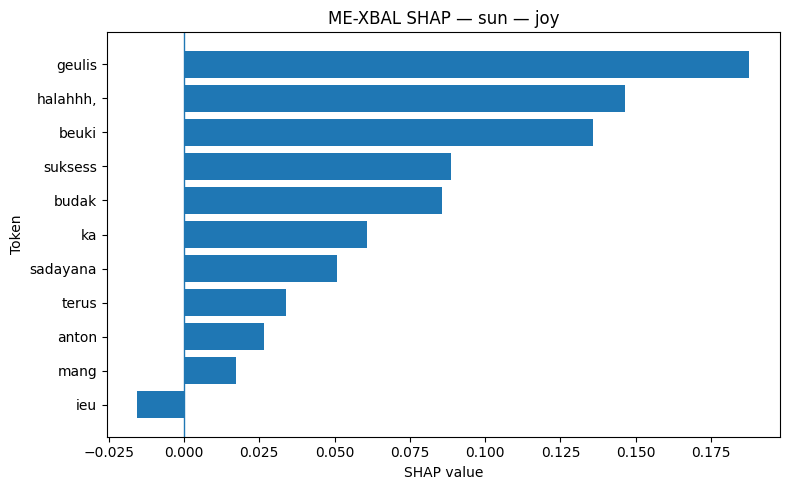

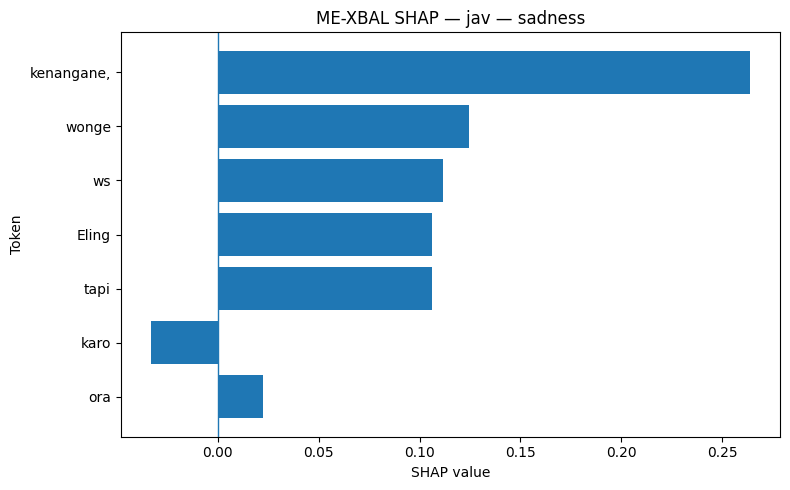

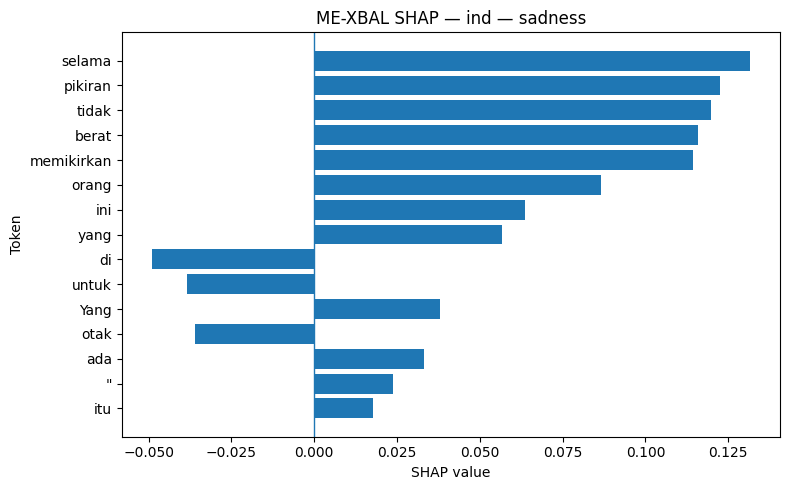

faithfulness sem:   0%|          | 0/30 [00:00<?, ?it/s]

skip (token mismatch) ind_140
     id lang target_class  probability                                                                                           text
sun_564  sun          joy     0.983408                           beuki geulis ieu budak mang anton halahhh, suksess terus ka sadayana
jav_128  jav      sadness     0.863282                                                       Eling kenangane, tapi ws ora karo wonge😢
ind_140  ind      sadness     0.948296 "Yang berat itu mereset otak untuk tidak memikirkan orang yang selama ini ada di dalam pikiran
dataset      test  n  shap_mean  random_mean  mean_difference  wilcoxon_stat  wilcoxon_p
SemEval  deletion 29   0.147919     0.022947         0.124972           38.0    0.000024
SemEval insertion 29   0.166086     0.072333         0.093752           40.0    0.000032


In [15]:
# ============================================================
# 16. SHAP — SemEval (examples + faithfulness, 10 texts per language)
# ============================================================
if RUN_SHAP:
    rng = np.random.default_rng(SEED_PRIMARY); sem_records, manifest = [], []
    for lang in SEMEVAL_DATA:
        te = SEMEVAL_SPLITS[(lang, SEED_PRIMARY)][2]
        p = combine(*proba_ml(SEM_B["tf"](SEMEVAL_EMB[MAIN_ENCODER][lang][te]), SEM_B["xm"], SEM_B["lm"]), SEM_B["w"])
        yt = SEMEVAL_DATA[lang][SEMEVAL_LABELS].values.astype(int)[te]
        pred = p.argmax(1); conf = p.max(1); correct = np.where(yt[np.arange(len(te)), pred] == 1)[0]
        cand = correct if len(correct) >= SHAP_SEM_PER_LANG else np.arange(len(te))
        chosen = cand[np.argsort(-conf[cand])][:SHAP_SEM_PER_LANG]
        for rank, li in enumerate(chosen):
            text = str(SEMEVAL_DATA[lang]["text"].iloc[int(te[li])]); tgt = int(pred[li])
            exp = explain([text], predictor("sem", tgt))[0]
            rec = {"id": f"{lang}_{int(te[li])}", "lang": lang, "text": text, "target_idx": tgt,
                   "target_class": SEMEVAL_LABELS[tgt], "probability": float(p[li, tgt]), "shap_values": exp.values}
            sem_records.append(rec)
            if rank == 0:   # most confident correct text = representative example
                df = save_token_plot(exp, f"ME-XBAL SHAP — {lang} — {SEMEVAL_LABELS[tgt]}", f"{SHAP_ROOT}/SemEval_SHAP_{lang}.png")
                df.to_csv(f"{SHAP_ROOT}/SemEval_SHAP_{lang}.csv", index=False)
                manifest.append({k: rec[k] for k in ["id", "lang", "target_class", "probability", "text"]})
    pd.DataFrame(manifest).to_csv(f"{SHAP_ROOT}/SemEval_SHAP_manifest.csv", index=False)
    sem_faith = faithfulness(sem_records, "sem", rng)
    sem_faith.to_csv(f"{SHAP_ROOT}/SemEval_SHAP_faithfulness_per_sample.csv", index=False)
    sem_sum = summarize(sem_faith, "SemEval"); sem_sum.to_csv(f"{SHAP_ROOT}/SemEval_SHAP_faithfulness_summary.csv", index=False)
    print(pd.DataFrame(manifest).to_string(index=False)); print(sem_sum.to_string(index=False))

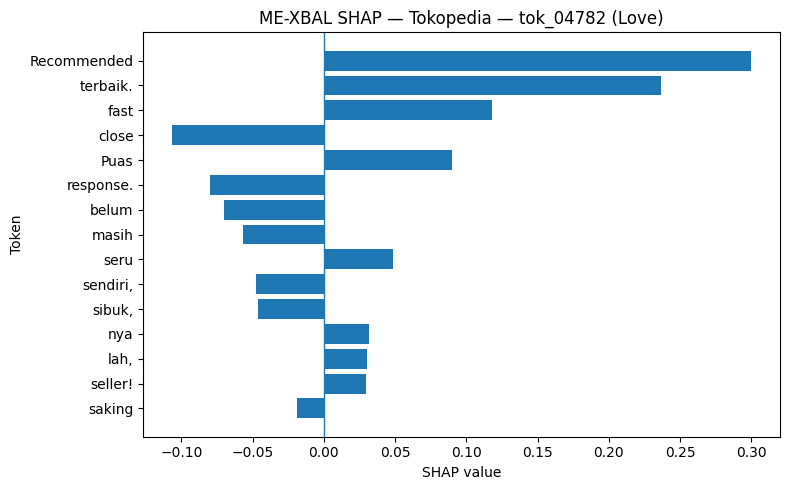

faithfulness tok:   0%|          | 0/30 [00:00<?, ?it/s]

Example: tok_04782 Love | Puas lah, fast response. Cuman masih sering close sendiri, saking sibuk, belum sempat dicek. Recommended seller! gaming terbaik. Game nya seru!
  dataset      test  n  shap_mean  random_mean  mean_difference  wilcoxon_stat  wilcoxon_p
Tokopedia  deletion 30   0.181874     0.057185         0.124688           68.0    0.000380
Tokopedia insertion 30   0.256376     0.116552         0.139823           37.0    0.000011


In [16]:
# ============================================================
# 17. SHAP — Tokopedia (30 stratified test reviews + faithfulness)
# ============================================================
if RUN_SHAP:
    rng = np.random.default_rng(SEED_PRIMARY)
    te = TOKO_SPLITS[SEED_PRIMARY][2]
    p_dec = combine(*proba_sl(TOK_B["tf"](TOKO_EMB[MAIN_ENCODER][te]), TOK_B["xm"], TOK_B["lm"]), TOK_B["w"]) * TOK_B["alpha"]
    pred = dict(zip(te, p_dec.argmax(1)))
    sel, _ = next(StratifiedShuffleSplit(n_splits=1, train_size=SHAP_TOK_N, random_state=SEED_PRIMARY)
                  .split(np.zeros(len(te)), TOKO_DF.label.values[te]))
    chosen = te[sel]; tok_records = []
    for tgt in sorted(set(int(pred[i]) for i in chosen)):
        idx = [i for i in chosen if int(pred[i]) == tgt]
        texts = [str(TOKO_DF["Customer Review"].iloc[int(i)]) for i in idx]
        exps = explain(texts, predictor("tok", tgt))
        for k, i in enumerate(idx):
            tok_records.append({"id": f"tok_{int(i):05d}", "lang": "ind", "text": texts[k], "target_idx": tgt,
                                "target_class": TOKO_CLASSES[tgt], "shap_values": exps[k].values, "exp": exps[k]})
    best = max(tok_records, key=lambda r: np.abs(np.asarray(r["shap_values"])).sum())   # representative example
    df = save_token_plot(best["exp"], f"ME-XBAL SHAP — Tokopedia — {best['id']} ({best['target_class']})", f"{SHAP_ROOT}/Tokopedia_SHAP.png")
    df.to_csv(f"{SHAP_ROOT}/Tokopedia_SHAP_example.csv", index=False)
    tok_faith = faithfulness(tok_records, "tok", rng)
    tok_faith.to_csv(f"{SHAP_ROOT}/Tokopedia_SHAP_faithfulness_per_sample.csv", index=False)
    tok_sum = summarize(tok_faith, "Tokopedia"); tok_sum.to_csv(f"{SHAP_ROOT}/Tokopedia_SHAP_faithfulness_summary.csv", index=False)
    print("Example:", best["id"], best["target_class"], "|", best["text"][:200]); print(tok_sum.to_string(index=False))

## 11. Environment record and archive

In [17]:
# ============================================================
# 18. ENVIRONMENT + ZIP
# ============================================================
env = {"python": platform.python_version(), "torch": torch.__version__, "transformers": transformers.__version__,
       "sklearn": sklearn.__version__, "xgboost": xgb.__version__, "numpy": np.__version__, "pandas": pd.__version__,
       "shap": shap.__version__ if RUN_SHAP else None, "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
       "seeds": SEEDS, "lc_seeds": LC_SEEDS, "lc_sizes": LC_SIZES, "smoke_test": SMOKE_TEST,
       "encoders": ENCODERS, "main_encoder": MAIN_ENCODER}
json.dump(env, open(f"{OUT_ROOT}/environment.json", "w"), indent=2)
shutil.make_archive(f"{WORK}/ME-XBAL_E5_outputs", "zip", OUT_ROOT)
print(json.dumps(env, indent=2)); print("Archive:", f"{WORK}/ME-XBAL_E5_outputs.zip")

{
  "python": "3.12.13",
  "torch": "2.10.0+cu128",
  "transformers": "5.0.0",
  "sklearn": "1.6.1",
  "xgboost": "3.2.0",
  "numpy": "2.0.2",
  "pandas": "2.3.3",
  "shap": "0.51.0",
  "gpu": "Tesla T4",
  "seeds": [
    42,
    7,
    13,
    77,
    101,
    202,
    303,
    404,
    505,
    606
  ],
  "lc_seeds": [
    42,
    7,
    13,
    77,
    101
  ],
  "lc_sizes": [
    100,
    250,
    500,
    750,
    1000,
    1500,
    2000,
    2500,
    3000,
    3510
  ],
  "smoke_test": false,
  "encoders": {
    "e5": {
      "name": "intfloat/multilingual-e5-base",
      "prefix": "query: "
    },
    "xlmr": {
      "name": "xlm-roberta-base",
      "prefix": null
    },
    "indobert": {
      "name": "indobenchmark/indobert-base-p1",
      "prefix": null
    }
  },
  "main_encoder": "e5"
}
Archive: /kaggle/working/ME-XBAL_E5_outputs.zip
